# 1. Import Library

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, roc_curve, auc, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# 2. Load Dataset

**2.1 Load Dataset**

In [109]:
df = pd.read_csv('Teen_Mental_Health.csv')
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,male,7.9,Facebook,7.4,2.9,3.01,1.5,low,2,2,1,0,5,Fair,At Risk
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0,19,Good,Moderate
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0,8,Fair,Healthy
3,15,male,7.4,YouTube,6.9,1.6,3.48,0.8,medium,1,7,9,0,17,Fair,Moderate
4,15,female,4.7,All Platforms,4.9,3.0,2.37,1.4,medium,3,5,2,0,10,Poor,Moderate


# 3. Data Understanding

**3.1 Informasi Dataset**

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_quality      

**3.2 Statistik Deskriptif**

In [111]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833,16.647500
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704,5.038128
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000,3.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000,13.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000,17.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000,20.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000,30.000000


**3.3 Dimensi Dataset**

In [112]:
print("Jumlah Baris dan Kolom:")
df.shape

Jumlah Baris dan Kolom:


(1200, 16)

**3.4 Missing Value**

In [113]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
mental_health_risk_score    0
sleep_quality               0
digital_wellbeing_flag      0
dtype: int64

**3.5 Duplicate Data**

In [114]:
df.duplicated().sum()

np.int64(0)

**3.6 Distribusi Target**

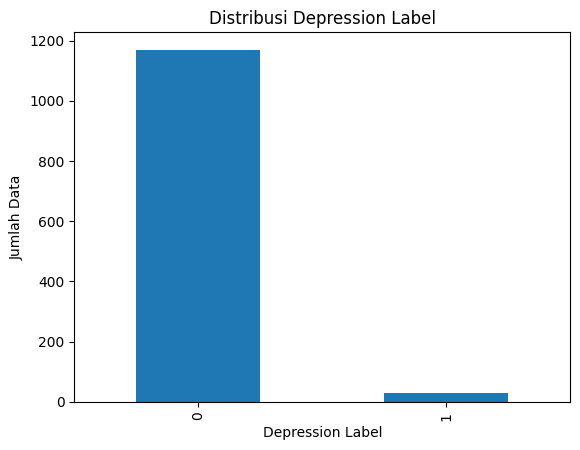

In [115]:
df['depression_label'].value_counts()

df['depression_label'].value_counts().plot(
    kind='bar'
)

plt.title('Distribusi Depression Label')
plt.xlabel('Depression Label')
plt.ylabel('Jumlah Data')
plt.show()

# 4. Data Preprocessing

**4.1 Label Encoding**

In [116]:
for col in [
    'gender',
    'platform_usage',
    'social_interaction_level',
    'sleep_quality'
]:
    le = LabelEncoder()
    le.fit(df[col])

    print(f"\n{col}")
    print(dict(zip(
        le.classes_,
        le.transform(le.classes_)
    )))


gender
{'female': np.int64(0), 'male': np.int64(1)}

platform_usage
{'All Platforms': np.int64(0), 'Facebook': np.int64(1), 'Instagram': np.int64(2), 'TikTok': np.int64(3), 'YouTube': np.int64(4)}

social_interaction_level
{'high': np.int64(0), 'low': np.int64(1), 'medium': np.int64(2)}

sleep_quality
{'Fair': np.int64(0), 'Good': np.int64(1), 'Poor': np.int64(2)}


In [117]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

C:\Users\fairuz nailah putri\AppData\Local\Temp\ipykernel_35524\302337938.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object'):


In [118]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,mental_health_risk_score,sleep_quality,digital_wellbeing_flag
0,14,1,7.9,1,7.4,2.9,3.01,1.5,1,2,2,1,0,5,0,0
1,19,0,1.9,3,8.0,2.9,3.22,0.8,0,8,1,10,0,19,1,2
2,17,0,1.3,2,7.6,0.5,3.92,0.0,0,2,4,2,0,8,0,1
3,15,1,7.4,4,6.9,1.6,3.48,0.8,2,1,7,9,0,17,0,2
4,15,0,4.7,0,4.9,3.0,2.37,1.4,2,3,5,2,0,10,2,2


In [119]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   int64  
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   int64  
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   int64  
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
 13  mental_health_risk_score  1200 non-null   int64  
 14  sleep_quality      

**4.2 Feature Selection**

In [120]:
X = df[
[
'age',
'gender',
'daily_social_media_hours',
'platform_usage',
'sleep_hours',
'screen_time_before_sleep',
'academic_performance',
'physical_activity',
'social_interaction_level',
'stress_level',
'anxiety_level',
'addiction_level',
'sleep_quality'
]
]

y = df['depression_label']

**4.3 Normalisasi Data**

In [121]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.95409872,  0.97530483,  1.6578328 , ..., -1.27233544,
        -1.613389  , -1.11501167],
       [ 1.51979597, -1.02532046, -1.29964891, ..., -1.62219852,
         1.56744364,  0.00186146],
       [ 0.5302381 , -1.02532046, -1.59539708, ..., -0.57260926,
        -1.25996315, -1.11501167],
       ...,
       [-0.95409872, -1.02532046, -1.39823163, ..., -1.62219852,
        -1.613389  ,  0.00186146],
       [-0.45931978,  0.97530483, -0.31382167, ...,  1.17670619,
         1.21401779,  0.00186146],
       [ 0.03545916, -1.02532046,  0.08050922, ...,  0.47698001,
        -0.9065373 , -1.11501167]], shape=(1200, 13))

# 5. Exploratory Data Analysis

**5.1 Distribusi Fitur Numerik**

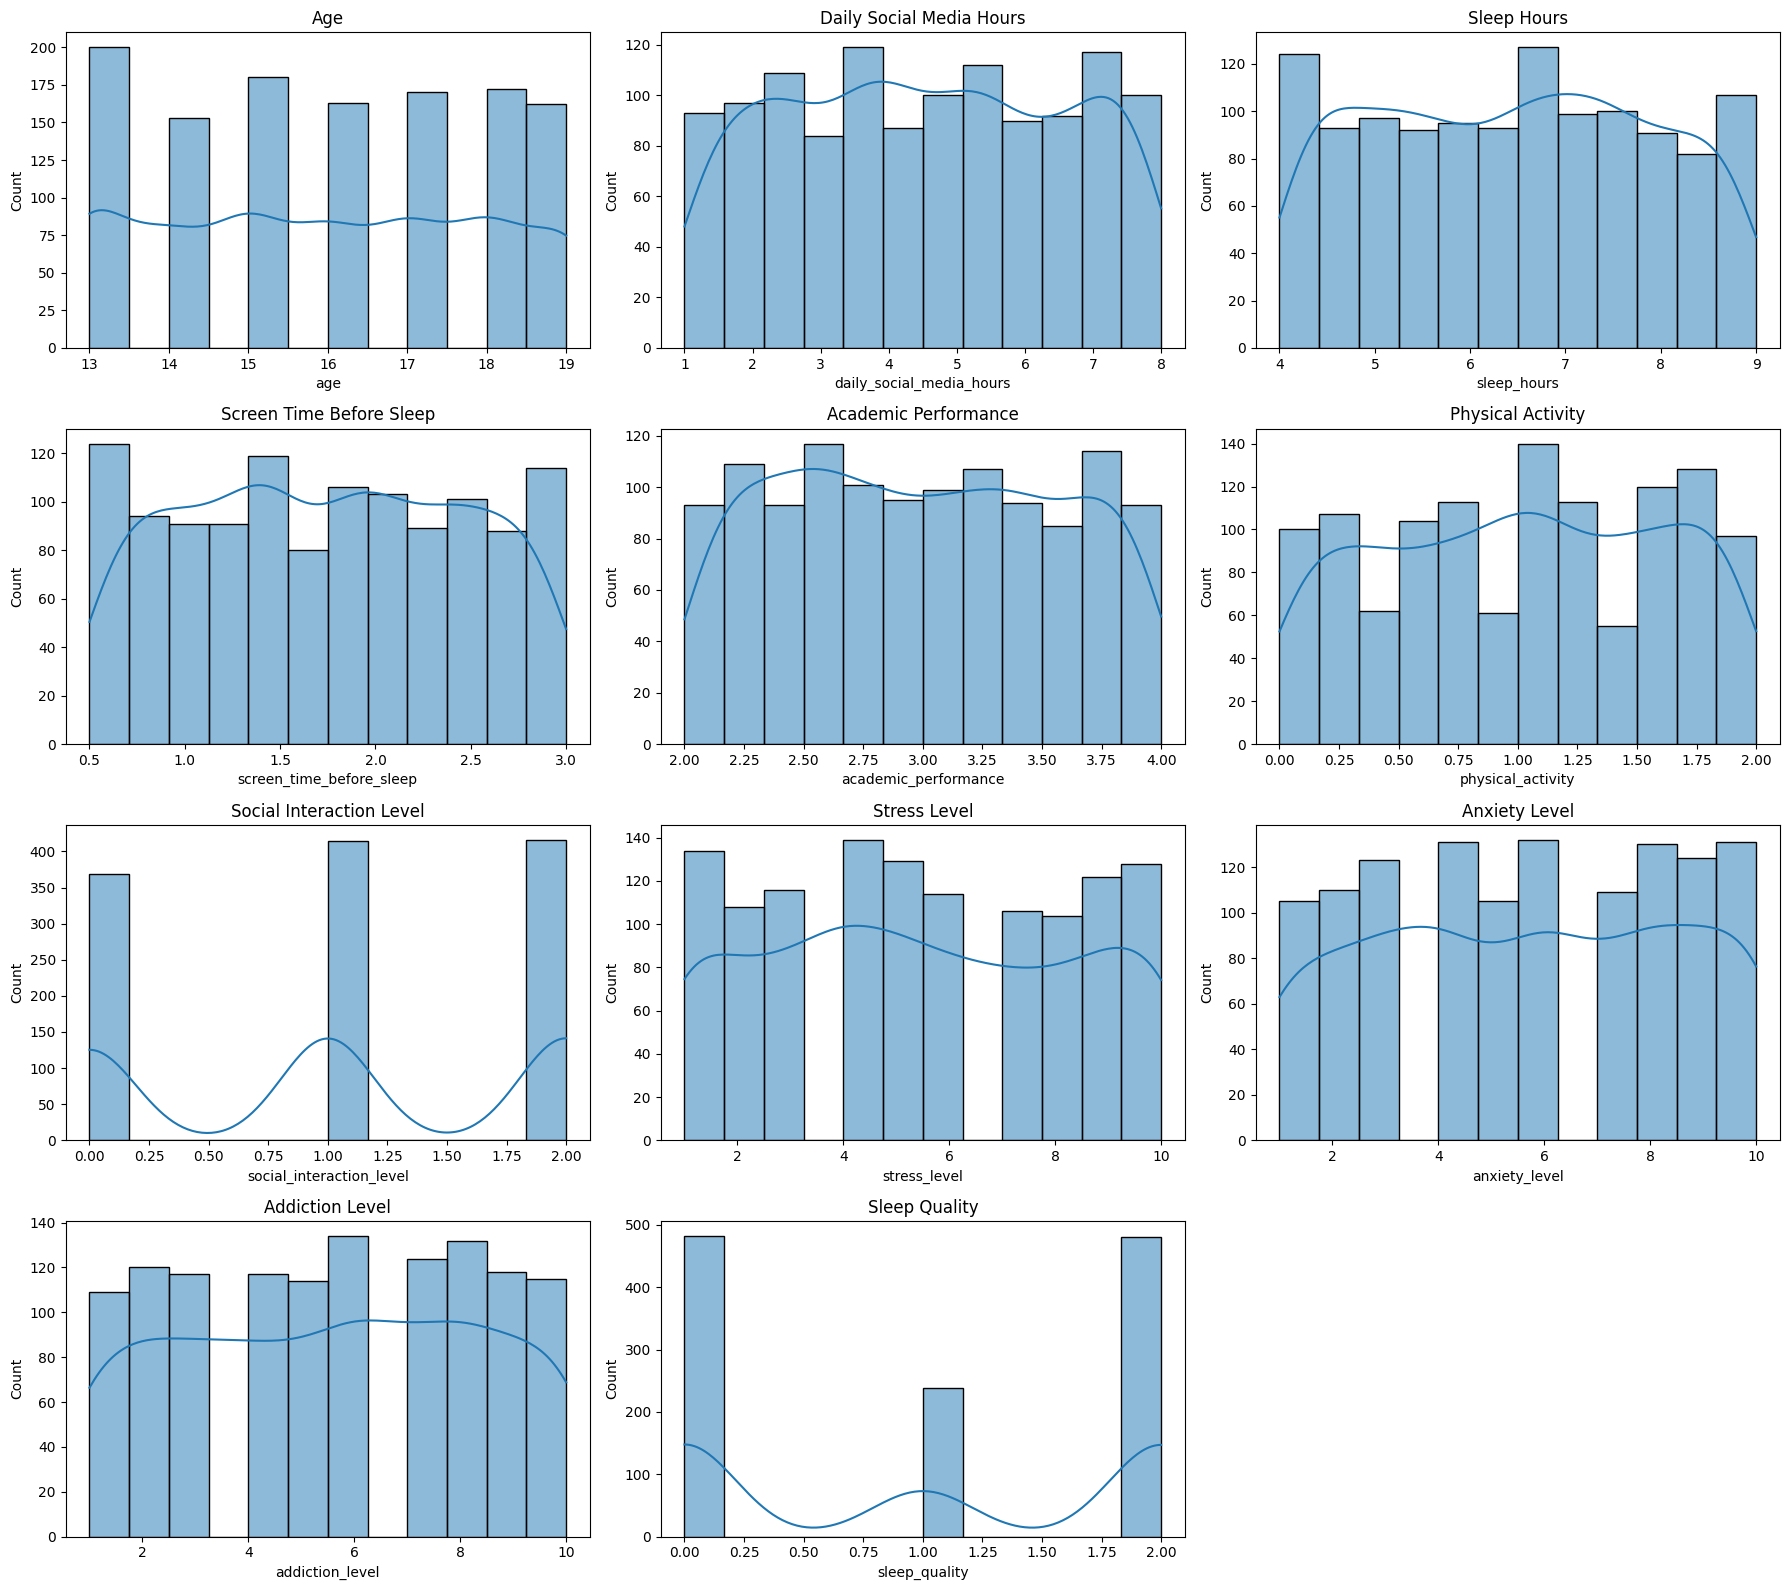

In [122]:
numeric_cols = [
    'age',
    'daily_social_media_hours',
    'sleep_hours',
    'screen_time_before_sleep',
    'academic_performance',
    'physical_activity',
    'social_interaction_level',
    'stress_level',
    'anxiety_level',
    'addiction_level',
    'sleep_quality'
]

fig, axes = plt.subplots(
    4,
    3,
    figsize=(18,16)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(
        col.replace('_',' ').title()
    )

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**5.2 Distribusi Fitur Kategorikal**

Visualisasi fitur kategorikal digunakan untuk melihat distribusi data pada atribut kategorikal seperti gender dan status depresi.

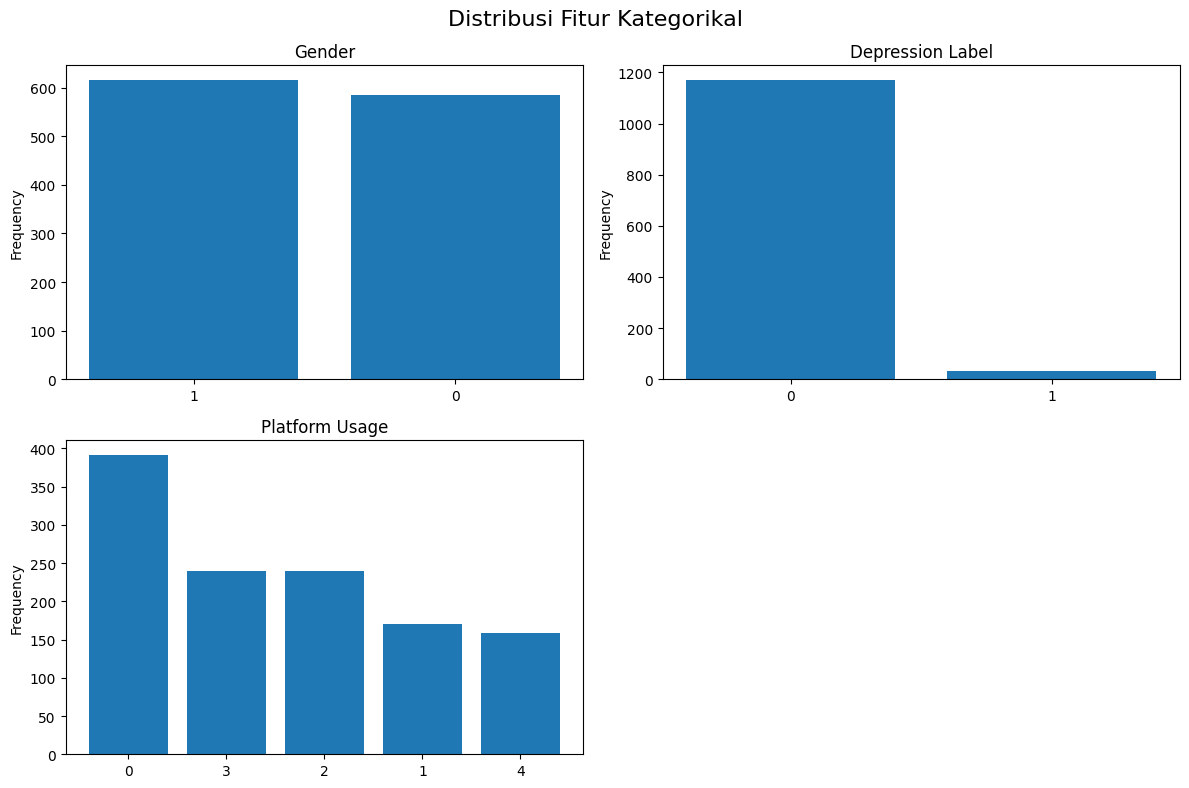

In [123]:
category_cols = [
    'gender',
    'depression_label',
    'platform_usage'
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,8)
)

axes = axes.flatten()

for i, col in enumerate(category_cols):

    counts = df[col].value_counts()

    axes[i].bar(
        counts.index.astype(str),
        counts.values
    )

    axes[i].set_title(
        col.replace('_',' ').title()
    )

    axes[i].set_ylabel('Frequency')

fig.delaxes(axes[3])

plt.suptitle(
    'Distribusi Fitur Kategorikal',
    fontsize=16
)

plt.tight_layout()

plt.show()

**5.3 Penggunaan Media Sosial terhadap Depresi**

Visualisasi ini digunakan untuk melihat perbedaan durasi penggunaan media sosial antara remaja yang mengalami depresi dan yang tidak mengalami depresi.

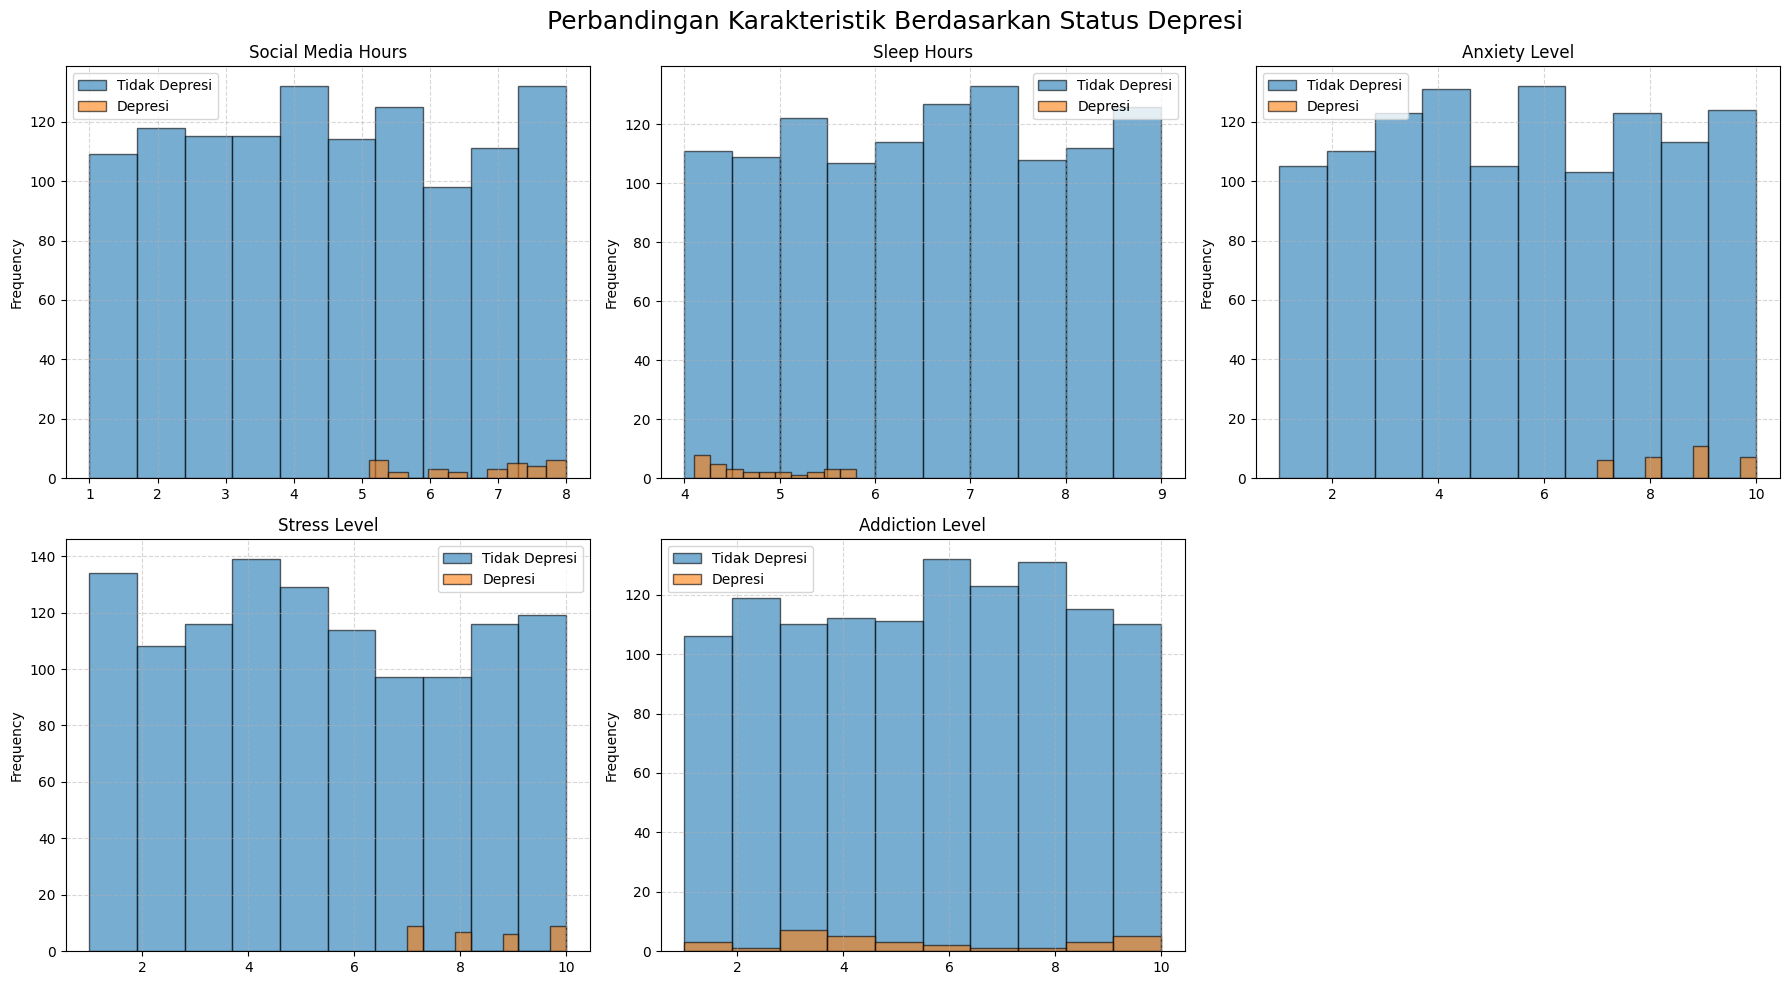

In [124]:
comparison_cols = [
    'daily_social_media_hours',
    'sleep_hours',
    'anxiety_level',
    'stress_level',
    'addiction_level'
]

titles = [
    'Social Media Hours',
    'Sleep Hours',
    'Anxiety Level',
    'Stress Level',
    'Addiction Level'
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18,10)
)

axes = axes.flatten()

for i, col in enumerate(comparison_cols):

    axes[i].hist(
        df[df['depression_label']==0][col],
        bins=10,
        alpha=0.6,
        label='Tidak Depresi',
        edgecolor='black'
    )

    axes[i].hist(
        df[df['depression_label']==1][col],
        bins=10,
        alpha=0.6,
        label='Depresi',
        edgecolor='black'
    )

    axes[i].set_title(titles[i])
    axes[i].set_ylabel('Frequency')
    axes[i].grid(
        linestyle='--',
        alpha=0.5
    )

    axes[i].legend()

# hapus subplot kosong terakhir
fig.delaxes(axes[5])

plt.suptitle(
    'Perbandingan Karakteristik Berdasarkan Status Depresi',
    fontsize=18
)

plt.tight_layout()

plt.show()

**5.4 Rata-rata Karakteristik Berdasarkan Status Depresi**

Tahap ini dilakukan untuk membandingkan rata-rata beberapa faktor yang berhubungan dengan kesehatan mental antara kelompok remaja yang mengalami depresi dan yang tidak mengalami depresi

In [125]:
mean_comparison = df.groupby('depression_label')[
[
    'daily_social_media_hours',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]
].mean()

mean_comparison

,daily_social_media_hours,sleep_hours,stress_level,anxiety_level,addiction_level
depression_label,,,,,
0,4.478785,6.494183,5.365269,5.557742,5.571429
1,6.719355,4.761290,8.483871,8.612903,5.322581


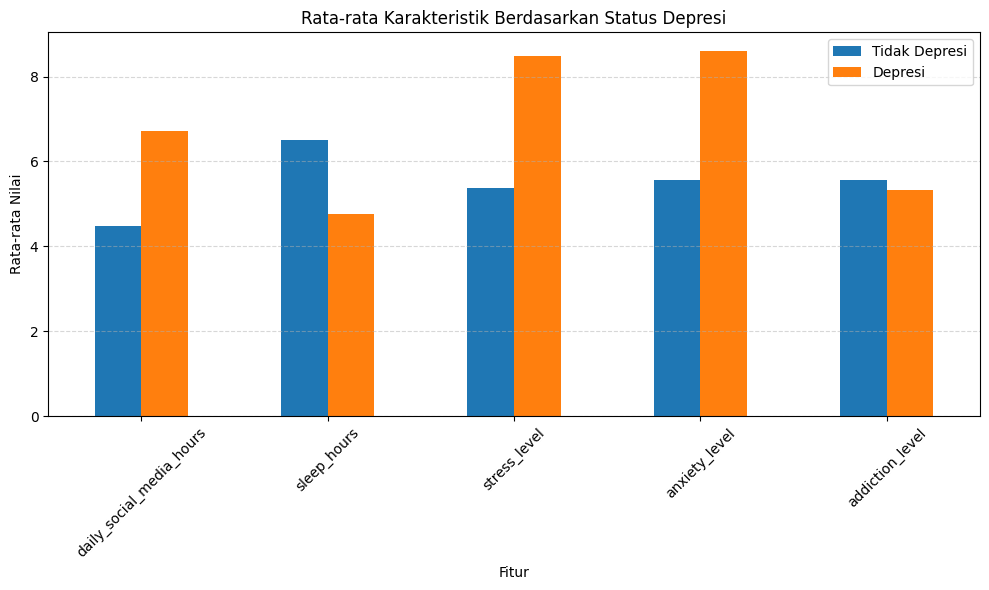

In [126]:
mean_comparison = df.groupby('depression_label')[
[
    'daily_social_media_hours',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]
].mean()

mean_comparison.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Rata-rata Karakteristik Berdasarkan Status Depresi'
)

plt.xlabel('Fitur')
plt.ylabel('Rata-rata Nilai')

plt.xticks(rotation=45)

plt.legend([
    'Tidak Depresi',
    'Depresi'
])

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

**5.5 Correlation Matrix**

Correlation Matrix digunakan untuk mengetahui hubungan antar variabel dalam dataset. Nilai korelasi berada pada rentang -1 hingga 1. Semakin mendekati 1 menunjukkan hubungan positif yang kuat, sedangkan semakin mendekati -1 menunjukkan hubungan negatif yang kuat.

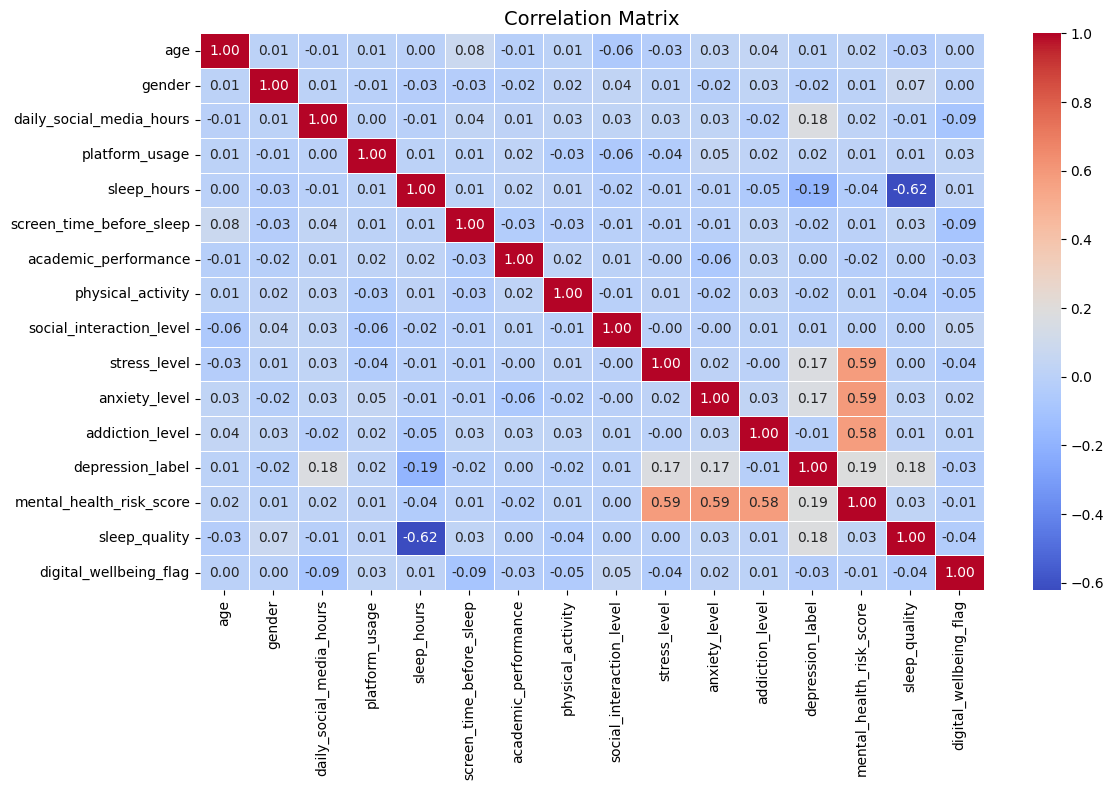

In [127]:
plt.figure(figsize=(12,8))

corr_matrix = df.corr()

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    'Correlation Matrix',
    fontsize=14
)

plt.tight_layout()
plt.show()

# 6. K-Means Clustering

**6.1 Menentukan Jumlah Cluster Optimal (Elbow Method)**

Metode Elbow digunakan untuk menentukan jumlah cluster yang optimal dengan melihat perubahan nilai inertia pada setiap jumlah cluster. Titik siku (elbow) menunjukkan jumlah cluster yang paling sesuai digunakan.

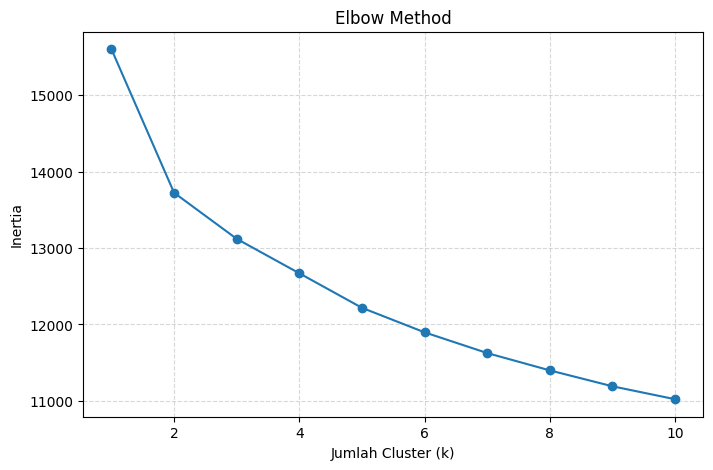

In [128]:
inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.title('Elbow Method')
plt.xlabel('Jumlah Cluster (k)')
plt.ylabel('Inertia')

plt.grid(
    linestyle='--',
    alpha=0.5
)

plt.show()

**6.2 Penerapan K-Means Clustering**

Setelah jumlah cluster ditentukan menggunakan metode Elbow, dilakukan proses clustering menggunakan algoritma K-Means dengan jumlah cluster sebanyak 3.

In [129]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df['clusters'] = clusters

**6.3 Distribusi Cluster**

Tahap ini dilakukan untuk mengetahui jumlah anggota pada setiap cluster yang terbentuk.

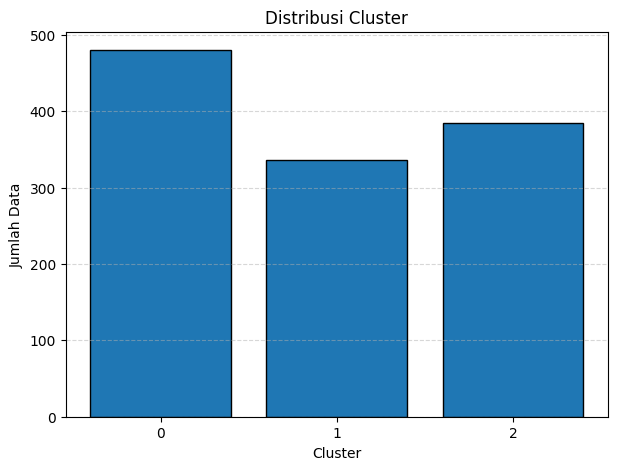

In [130]:
df['clusters'].value_counts()

cluster_count = df['clusters'].value_counts().sort_index()

plt.figure(figsize=(7,5))

plt.bar(
    cluster_count.index.astype(str),
    cluster_count.values,
    edgecolor='black'
)

plt.title('Distribusi Cluster')
plt.xlabel('Cluster')
plt.ylabel('Jumlah Data')

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.show()

Hasil K-Means Clustering menghasilkan 3 cluster. Cluster 0 memiliki 480 anggota, Cluster 1 memiliki 338 anggota, dan Cluster 2 memiliki 382 anggota. Hal ini menunjukkan bahwa sebagian besar data tergabung ke dalam Cluster 0.

**6.4 Profil Cluster**

Profil cluster digunakan untuk mengetahui karakteristik masing-masing cluster berdasarkan rata-rata nilai fitur yang digunakan dalam proses clustering.

In [131]:
cluster_profile = df.groupby('clusters')[
[
    'daily_social_media_hours',
    'sleep_hours',
    'stress_level',
    'anxiety_level',
    'addiction_level'
]
].mean()

cluster_profile

,daily_social_media_hours,sleep_hours,stress_level,anxiety_level,addiction_level
clusters,,,,,
0,4.534583,4.945625,5.495833,5.685417,5.656250
1,4.309524,7.413095,4.922619,5.625000,5.568452
2,4.738021,7.485937,5.841146,5.585938,5.447917


**6.5 Visualisasi Profil Cluster**

Visualisasi ini digunakan untuk mempermudah perbandingan karakteristik setiap cluster yang terbentuk.

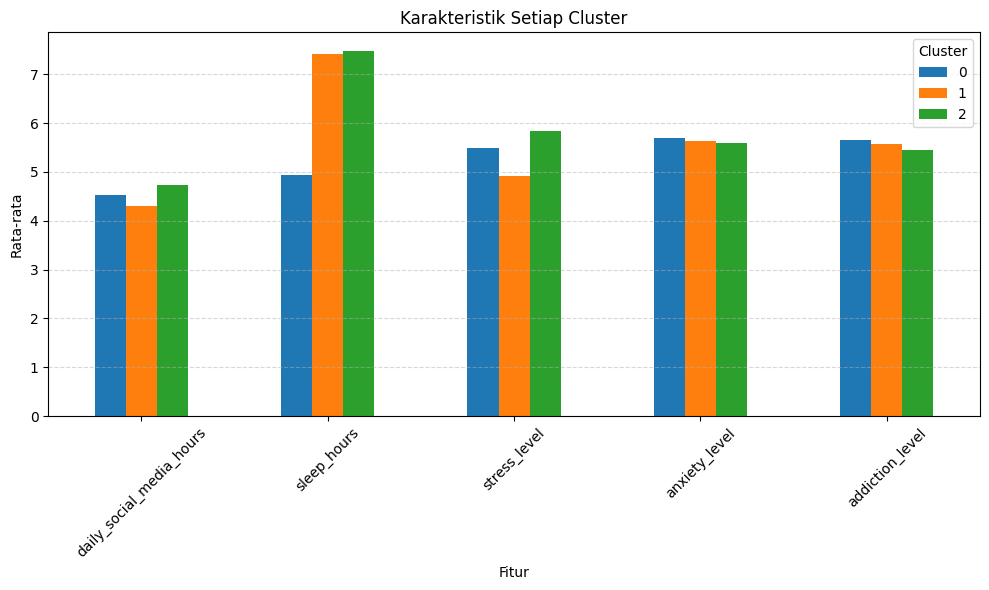

In [132]:
cluster_profile.T.plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Karakteristik Setiap Cluster'
)

plt.xlabel('Fitur')
plt.ylabel('Rata-rata')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.legend(
    title='Cluster'
)

plt.tight_layout()

plt.show()

**6.6 Distribusi Depression Label pada Setiap Cluster**

In [133]:
pd.crosstab(
    df['clusters'],
    df['depression_label']
)

depression_label,0,1
clusters,,
0,449,31
1,336,0
2,384,0


## 7. Data Splitting

Dataset dibagi menjadi data latih (training data) dan data uji (testing data). Data latih digunakan untuk membangun model, sedangkan data uji digunakan untuk mengevaluasi performa model.

In [134]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X Train :", X_train.shape)
print("X Test  :", X_test.shape)
print("y Train :", y_train.shape)
print("y Test  :", y_test.shape)

X Train : (960, 13)
X Test  : (240, 13)
y Train : (960,)
y Test  : (240,)


# 8. Logistic Regression

**8.1 Membangun Model**

Logistic Regression digunakan untuk memprediksi kondisi depresi berdasarkan karakteristik penggunaan media sosial dan kesehatan mental remaja.

In [135]:
logreg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logreg.fit(
    X_train,
    y_train
)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

**8.2 Prediksi**

Model yang telah dilatih digunakan untuk memprediksi kondisi depresi pada data uji.

In [136]:
y_pred_lr = logreg.predict(X_test)

y_pred_lr[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**8.3 Accuracy Score**

Accuracy digunakan untuk mengukur persentase prediksi yang benar terhadap seluruh data uji.

In [137]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print(
    "Accuracy Logistic Regression:",
    accuracy_lr
)

Accuracy Logistic Regression: 0.9875


**8.4 Classification Report**

Classification Report digunakan untuk mengevaluasi performa model berdasarkan nilai precision, recall, dan f1-score.

In [138]:
print(
    classification_report(
        y_test,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       234
           1       1.00      0.50      0.67         6

    accuracy                           0.99       240
   macro avg       0.99      0.75      0.83       240
weighted avg       0.99      0.99      0.99       240



**8.5 Confusion Matrix**

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada masing-masing kelas.

[[234   0]
 [  3   3]]


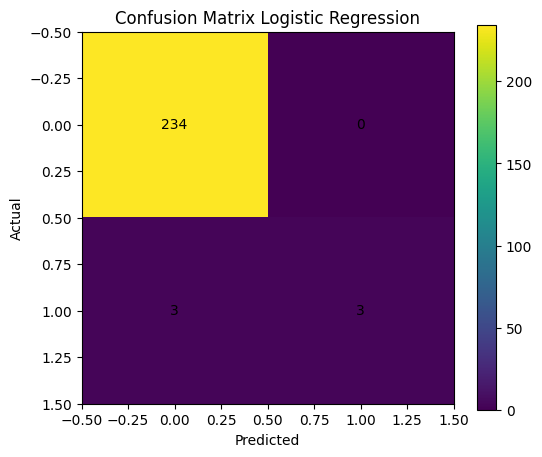

In [139]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

print(cm_lr)

plt.figure(figsize=(6,5))

plt.imshow(cm_lr)

plt.colorbar()

plt.title(
    'Confusion Matrix Logistic Regression'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(cm_lr.shape[0]):
    for j in range(cm_lr.shape[1]):
        plt.text(
            j,
            i,
            cm_lr[i, j],
            ha='center',
            va='center'
        )

plt.show()

# 9. Naive Bayes

**9.1 Membangun Model Naive Bayes**

Naive Bayes merupakan algoritma klasifikasi berbasis probabilitas yang menggunakan Teorema Bayes. Algoritma ini digunakan untuk memprediksi kondisi depresi berdasarkan fitur-fitur yang terdapat pada dataset.

In [140]:
nb = GaussianNB()

nb.fit(
    X_train,
    y_train
)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


**9.2 Prediksi**

Model Naive Bayes yang telah dilatih digunakan untuk melakukan prediksi terhadap data uji.

In [141]:
y_pred_nb = nb.predict(X_test)
y_pred_nb[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

**9.3 Accuracy Score**

Accuracy digunakan untuk mengukur persentase prediksi yang benar dibandingkan dengan seluruh data uji.

In [142]:
accuracy_nb = accuracy_score(
    y_test,
    y_pred_nb
)

print(
    "Accuracy Naive Bayes:",
    accuracy_nb
)

Accuracy Naive Bayes: 0.9041666666666667


**9.4 Classification Report**

Classification Report digunakan untuk mengevaluasi performa model berdasarkan nilai precision, recall, dan f1-score pada masing-masing kelas.

In [143]:
print(
    classification_report(
        y_test,
        y_pred_nb
    )
)

              precision    recall  f1-score   support

           0       1.00      0.90      0.95       234
           1       0.21      1.00      0.34         6

    accuracy                           0.90       240
   macro avg       0.60      0.95      0.65       240
weighted avg       0.98      0.90      0.93       240



**9.5 Confusion Matrix**

Confusion Matrix digunakan untuk melihat jumlah prediksi yang benar dan salah pada setiap kelas sehingga performa model dapat dianalisis lebih detail.

[[211  23]
 [  0   6]]


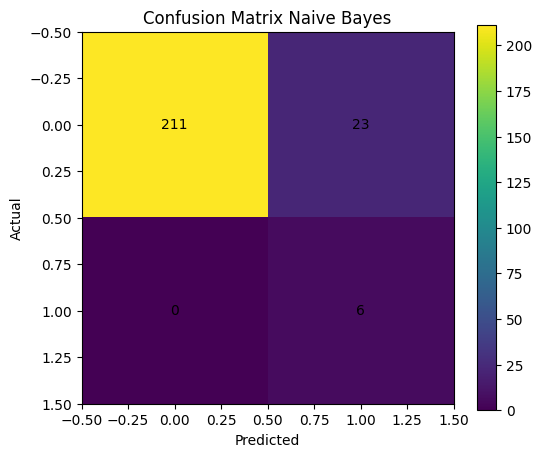

In [144]:
cm_nb = confusion_matrix(
    y_test,
    y_pred_nb
)

print(cm_nb)

plt.figure(figsize=(6,5))

plt.imshow(cm_nb)

plt.colorbar()

plt.title(
    'Confusion Matrix Naive Bayes'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

for i in range(cm_nb.shape[0]):
    for j in range(cm_nb.shape[1]):
        plt.text(
            j,
            i,
            cm_nb[i, j],
            ha='center',
            va='center'
        )

plt.show()

**9.6 Interpretasi Hasil Naive Bayes**

Berdasarkan hasil pengujian menggunakan algoritma Naive Bayes, diperoleh nilai accuracy sebesar 90,42%. Nilai tersebut menunjukkan bahwa sebagian besar data uji berhasil diprediksi dengan benar oleh model.

Hasil classification report menunjukkan bahwa model memiliki recall sebesar 100% pada kelas depresi, yang berarti seluruh data depresi berhasil terdeteksi oleh model. Namun, precision pada kelas depresi hanya sebesar 21%, yang menunjukkan bahwa masih terdapat cukup banyak prediksi depresi yang sebenarnya bukan depresi.

Berdasarkan confusion matrix, model berhasil mengklasifikasikan 211 data tidak depresi dan 6 data depresi dengan benar. Akan tetapi, terdapat 23 data tidak depresi yang diprediksi sebagai depresi (false positive).

# 10. Perbandingan Model

In [145]:
model_comparison = pd.DataFrame({

    'Model': [
        'Logistic Regression',
        'Naive Bayes'
    ],

    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_nb)
    ],

    'Precision (Depresi)': [
        precision_score(y_test, y_pred_lr, pos_label=1),
        precision_score(y_test, y_pred_nb, pos_label=1)
    ],

    'Recall (Depresi)': [
        recall_score(y_test, y_pred_lr, pos_label=1),
        recall_score(y_test, y_pred_nb, pos_label=1)
    ],

    'F1-Score (Depresi)': [
        f1_score(y_test, y_pred_lr, pos_label=1),
        f1_score(y_test, y_pred_nb, pos_label=1)
    ]

})

model_comparison = model_comparison.round(3)

model_comparison

,Model,Accuracy,Precision (Depresi),Recall (Depresi),F1-Score (Depresi)
0,Logistic Regression,0.988,1.000,0.5,0.667
1,Naive Bayes,0.904,0.207,1.0,0.343


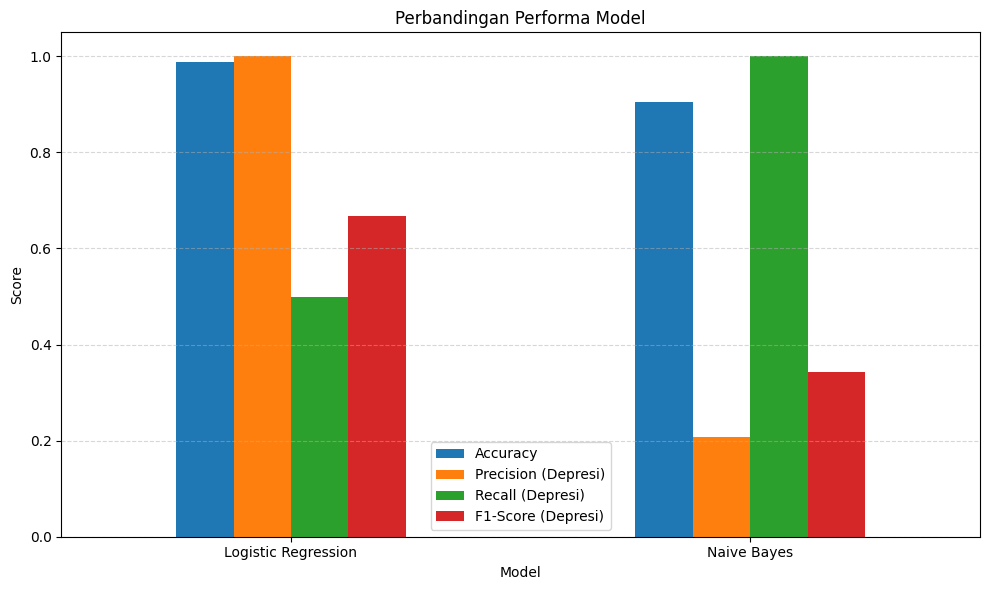

In [146]:
model_comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title(
    'Perbandingan Performa Model'
)

plt.ylabel('Score')

plt.xticks(rotation=0)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.5
)

plt.tight_layout()

plt.show()

# 11. Deployment

In [147]:
import joblib

joblib.dump(logreg, 'logistic_model.pkl')
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [148]:
%pip install streamlit

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: C:\Users\fairuz nailah putri\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


# KESIMPULAN

**Berdasarkan hasil evaluasi model, Logistic Regression memberikan performa terbaik dengan accuracy sebesar 98.8%.
Model ini memiliki precision sebesar 100%, recall sebesar 50%, dan F1-score sebesar 66.7%.
Oleh karena itu, Logistic Regression dipilih sebagai model utama untuk melakukan prediksi kondisi depresi pada remaja.**